# BM25 Baseline - Lexical Retrieval
Ablasi model retrieval untuk QA produk kecantikan (Shopee, Bahasa Indonesia).
BM25 (Okapi BM25) lexical sparse retrieval, tanpa encoder neural / tanpa training.
Tiga paradigma (Pointwise, Pairwise, Listwise) tetap dievaluasi dalam satu notebook dengan metrik ranking @k yang identik seperti model lain.

In [1]:
!pip install -q rank_bm25

model = 'BM25'

import os
import csv
import time
import re
import pickle
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from rank_bm25 import BM25Okapi

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = '/kaggle/input/datasets/user235162736/shopee-gemastik-v3'
TRAIN_PATH = f'{DATA_DIR}/beauty-product-review-train-v3.csv'
VAL_PATH = f'{DATA_DIR}/beauty-product-review-val-v3.csv'
TEST_PATH = f'{DATA_DIR}/beauty-product-review-test-v3.csv'
WORK_DIR = '/kaggle/working'

K_VALUES = [3, 5, 10]
METRIC_NAMES = ['precision', 'recall', 'f1', 'map', 'ndcg']
PARADIGMS = ['pointwise', 'pairwise', 'listwise']
MAX_NEG_PER_POS = 4
TEST_SIZE = 0.15
VAL_SIZE = 0.15

BM25_K1 = 1.5
BM25_B = 0.75

print(f'[{model}] bm25_k1={BM25_K1} bm25_b={BM25_B}')

[BM25] bm25_k1=1.5 bm25_b=0.75


In [2]:
def load_split(path):
    df = pd.read_csv(path)
    df['Question_clean'] = df['Question_clean'].fillna('').astype(str)
    df['Answer_clean'] = df['Answer_clean'].fillna('').astype(str)
    df['label'] = df['label'].astype(int)
    df = df[df['Answer_clean'].str.strip() != '']
    return df

train_df = load_split(TRAIN_PATH)
val_df = load_split(VAL_PATH)
test_df = load_split(TEST_PATH)

assert not (set(train_df['product_id']) & set(val_df['product_id']))
assert not (set(train_df['product_id']) & set(test_df['product_id']))
assert not (set(val_df['product_id']) & set(test_df['product_id']))

ANSWER_POOL = train_df['Answer_clean'].unique().tolist()

for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'[{model}] {name} rows={len(d)} products={d["product_id"].nunique()} pos={int((d.label == 1).sum())} neg={int((d.label == 0).sum())}')

[BM25] train rows=2200 products=220 pos=570 neg=1630
[BM25] val rows=270 products=27 pos=60 neg=210
[BM25] test rows=280 products=28 pos=79 neg=201


In [3]:
def build_eval(df, split):
    products = {}
    queries = []
    for pid, g in df.groupby('product_id'):
        row_ids = g['ID'].tolist()
        cand = g['Answer_clean'].tolist()
        id_to_pos = {rid: i for i, rid in enumerate(row_ids)}
        products[pid] = cand
        for q, qg in g.groupby('Question_clean'):
            y = np.zeros(len(cand), dtype=np.int32)
            grade = np.zeros(len(cand), dtype=np.float64)
            for _, row in qg.iterrows():
                pos = id_to_pos[row['ID']]
                if int(row['label']) == 1:
                    y[pos] = 1
                    rk = row['rank']
                    grade[pos] = 1.0 / float(rk) if pd.notna(rk) and float(rk) > 0 else 1.0
            if y.sum() == 0:
                continue
            queries.append({'pid': pid, 'question': q, 'y_true': y, 'y_grade': grade, 'n_rel': int(y.sum())})
    sizes = [len(c) for c in products.values()]
    nrels = [qd['n_rel'] for qd in queries]
    print(f'[{model}] {split} products={len(products)} queries={len(queries)} cand/product min={min(sizes)} max={max(sizes)} mean={np.mean(sizes):.1f} n_rel/query min={min(nrels)} max={max(nrels)} mean={np.mean(nrels):.2f}')
    return products, queries

val_products, val_queries = build_eval(val_df, 'val')
test_products, test_queries = build_eval(test_df, 'test')

[BM25] val products=27 queries=27 cand/product min=10 max=10 mean=10.0 n_rel/query min=1 max=6 mean=2.22
[BM25] test products=28 queries=28 cand/product min=10 max=10 mean=10.0 n_rel/query min=1 max=7 mean=2.82


In [4]:
def dcg(gains):
    gains = np.asarray(gains, dtype=np.float64)
    return float(np.sum(gains / np.log2(np.arange(2, gains.size + 2))))

def metrics_at_k(order, y_true, y_grade, k):
    topk = order[:k]
    rel = y_true[topk]
    n_rel = int(y_true.sum())
    hit = int(rel.sum())
    precision = hit / k
    recall = hit / n_rel if n_rel else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    ap = 0.0
    c = 0
    for i, g in enumerate(rel):
        if g:
            c += 1
            ap += c / (i + 1)
    ap = ap / min(n_rel, k) if n_rel else 0.0
    gains = y_grade[topk]
    ideal = np.sort(y_grade)[::-1][:k]
    idcg = dcg(ideal)
    ndcg = dcg(gains) / idcg if idcg else 0.0
    return precision, recall, f1, ap, ndcg

In [5]:
class TrainingLogger:
    def __init__(self, log_path, fieldnames):
        self.log_path = log_path
        self.fieldnames = fieldnames
        if not os.path.exists(log_path):
            with open(log_path, 'w', newline='') as f:
                writer = csv.DictWriter(f, fieldnames=fieldnames)
                writer.writeheader()

    def log(self, row_dict):
        with open(self.log_path, 'a', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=self.fieldnames)
            writer.writerow(row_dict)

LOG_FIELDS = ['epoch', 'step', 'train_loss', 'val_loss', 'val_map_10', 'val_f1_10', 'val_precision_10', 'val_recall_10', 'val_ndcg_3', 'val_ndcg_5', 'val_ndcg_10']

In [6]:
def build_pointwise(df):
    data = [(r['Question_clean'], r['Answer_clean'], float(r['label'])) for _, r in df.iterrows()]
    print(f'[{model}][pointwise] samples={len(data)} pos={int(sum(d[2] for d in data))} neg={int(sum(1 - d[2] for d in data))}')
    return data

def build_pairwise(df, pool):
    data = []
    for pid, g in df.groupby('product_id'):
        prod_neg = g.loc[g.label == 0, 'Answer_clean'].tolist()
        for q, qg in g.groupby('Question_clean'):
            pos = qg.loc[qg.label == 1, 'Answer_clean'].tolist()
            neg = qg.loc[qg.label == 0, 'Answer_clean'].tolist()
            if not neg:
                neg = prod_neg
            for p in pos:
                src = neg if neg else random.sample(pool, min(len(pool), MAX_NEG_PER_POS + 1))
                cands = [n for n in src if n != p]
                for n in random.sample(cands, min(len(cands), MAX_NEG_PER_POS)):
                    data.append((q, p, n))
    print(f'[{model}][pairwise] triples={len(data)}')
    return data

def build_listwise(df):
    data = []
    for pid, g in df.groupby('product_id'):
        cand = list(dict.fromkeys(g['Answer_clean'].tolist()))
        idx = {a: i for i, a in enumerate(cand)}
        for q, qg in g.groupby('Question_clean'):
            pos_idx = [idx[a] for a in set(qg.loc[qg.label == 1, 'Answer_clean'].tolist()) if a in idx]
            if not pos_idx or len(cand) < 2:
                continue
            data.append((q, cand, pos_idx))
    print(f'[{model}][listwise] lists={len(data)}')
    return data

def build_train_data(paradigm, df, pool):
    if paradigm == 'pointwise':
        return build_pointwise(df)
    if paradigm == 'pairwise':
        return build_pairwise(df, pool)
    return build_listwise(df)

In [7]:
TOKEN_RE = re.compile(r"\w+", re.UNICODE)

def tokenize(text):
    return TOKEN_RE.findall(str(text).lower())

def build_bm25(cand):
    tokenized = [tokenize(c) for c in cand]
    return BM25Okapi(tokenized, k1=BM25_K1, b=BM25_B)

In [8]:
def evaluate(products, queries, split, paradigm, measure_latency=False):
    prod_bm25 = {}
    for pid, cand in tqdm(products.items(), desc=f'[{model}][{paradigm}] index-cand {split}'):
        prod_bm25[pid] = build_bm25(cand)
    agg = {(m, k): [] for m in METRIC_NAMES for k in K_VALUES}
    latencies = []
    for qd in tqdm(queries, desc=f'[{model}][{paradigm}] eval {split}'):
        bm25 = prod_bm25[qd['pid']]
        t0 = time.perf_counter()
        scores = np.asarray(bm25.get_scores(tokenize(qd['question'])))
        order = np.argsort(-scores)
        if measure_latency:
            latencies.append((time.perf_counter() - t0) * 1000.0)
        for k in K_VALUES:
            p, r, f, ap, nd = metrics_at_k(order, qd['y_true'], qd['y_grade'], k)
            agg[('precision', k)].append(p)
            agg[('recall', k)].append(r)
            agg[('f1', k)].append(f)
            agg[('map', k)].append(ap)
            agg[('ndcg', k)].append(nd)
    result = {mk: float(np.mean(v)) for mk, v in agg.items()}
    latency = float(np.mean(latencies)) if latencies else None
    return result, latency

In [9]:
def train_paradigm(paradigm, data, val_products, val_queries, select_metric=('map', 10)):
    print(f'[{model}][{paradigm}] BM25 non-parametrik, tidak ada proses training/epoch.')
    return None

In [10]:
records = []
latency_ms = {}

for paradigm in PARADIGMS:
    print(f'\n[{model}] ===== evaluating paradigm: {paradigm} =====')
    data = build_train_data(paradigm, train_df, ANSWER_POOL)
    train_paradigm(paradigm, data, val_products, val_queries)

    val_res, _ = evaluate(val_products, val_queries, 'val', paradigm)
    test_res, test_lat = evaluate(test_products, test_queries, 'test', paradigm, measure_latency=True)
    latency_ms[paradigm] = test_lat

    for split, res in [('val', val_res), ('test', test_res)]:
        for (metric, k), score in res.items():
            records.append({'model': model, 'paradigm': paradigm, 'split': split, 'metric': metric, 'k': k, 'score': score})

    print(f'[{model}][{paradigm}] test_latency_ms/query={test_lat:.2f}')
    for split, res in [('val', val_res), ('test', test_res)]:
        print(f'[{model}][{paradigm}] --- {split} ---')
        for k in K_VALUES:
            print(f'[{model}][{paradigm}][{split}] k={k} '
                  f'P={res[("precision", k)]:.4f} R={res[("recall", k)]:.4f} '
                  f'F1={res[("f1", k)]:.4f} MAP={res[("map", k)]:.4f} NDCG={res[("ndcg", k)]:.4f}')


[BM25] ===== evaluating paradigm: pointwise =====
[BM25][pointwise] samples=2200 pos=570 neg=1630
[BM25][pointwise] BM25 non-parametrik, tidak ada proses training/epoch.


[BM25][pointwise] index-cand val:   0%|          | 0/27 [00:00<?, ?it/s]

[BM25][pointwise] eval val:   0%|          | 0/27 [00:00<?, ?it/s]

[BM25][pointwise] index-cand test:   0%|          | 0/28 [00:00<?, ?it/s]

[BM25][pointwise] eval test:   0%|          | 0/28 [00:00<?, ?it/s]

...

[BM25][listwise] index-cand val:   0%|          | 0/27 [00:00<?, ?it/s]

[BM25][listwise] eval val:   0%|          | 0/27 [00:00<?, ?it/s]

[BM25][listwise] index-cand test:   0%|          | 0/28 [00:00<?, ?it/s]

[BM25][listwise] eval test:   0%|          | 0/28 [00:00<?, ?it/s]

[BM25][listwise] test_latency_ms/query=0.18
[BM25][listwise] --- val ---
[BM25][listwise][val] k=3 P=0.4568 R=0.7160 F1=0.5170 MAP=0.6800 NDCG=0.7514
[BM25][listwise][val] k=5 P=0.3556 R=0.8333 F1=0.4662 MAP=0.7306 NDCG=0.7952
[BM25][listwise][val] k=10 P=0.2222 R=1.0000 F1=0.3467 MAP=0.7812 NDCG=0.8419
[BM25][listwise] --- test ---
[BM25][listwise][test] k=3 P=0.5595 R=0.6901 F1=0.5562 MAP=0.7510 NDCG=0.7839
[BM25][listwise][test] k=5 P=0.4500 R=0.8647 F1=0.5390 MAP=0.7611 NDCG=0.8292
[BM25][listwise][test] k=10 P=0.2821 R=1.0000 F1=0.4116 MAP=0.8093 NDCG=0.8675


In [11]:
log_df = pd.DataFrame(records)
log_df.to_csv(f'{WORK_DIR}/log_{model}.csv', index=False)
print(f'[{model}] saved {WORK_DIR}/log_{model}.csv rows={len(log_df)}')

save_obj = {
    'model': model,
    'bm25_k1': BM25_K1,
    'bm25_b': BM25_B,
    'k_values': K_VALUES,
    'results': records,
    'latency_ms': latency_ms,
}
with open(f'{WORK_DIR}/bprqa_{model}.pkl', 'wb') as f:
    pickle.dump(save_obj, f)
print(f'[{model}] saved {WORK_DIR}/bprqa_{model}.pkl')

[BM25] saved /kaggle/working/log_BM25.csv rows=90
[BM25] saved /kaggle/working/bprqa_BM25.pkl


In [12]:
summary = log_df.pivot_table(index=['paradigm', 'metric', 'k'], columns='split', values='score').reset_index()
summary = summary.sort_values(['paradigm', 'metric', 'k']).reset_index(drop=True)
print(f'[{model}] evaluation summary (val vs test)')
print(summary.to_string(index=False))
print(f'\n[{model}] mean test latency ms/query per paradigm:')
for p in PARADIGMS:
    print(f'[{model}][{p}] {latency_ms[p]:.2f} ms')

[BM25] evaluation summary (val vs test)
 paradigm    metric  k     test      val
 listwise        f1  3 0.556207 0.516990
 listwise        f1  5 0.539031 0.466236
 listwise        f1 10 0.411614 0.346730
 listwise       map  3 0.750992 0.680041
 listwise       map  5 0.761062 0.730566
 listwise       map 10 0.809287 0.781151
 listwise      ndcg  3 0.783945 0.751408
 listwise      ndcg  5 0.829184 0.795235
 listwise      ndcg 10 0.867530 0.841924
 listwise precision  3 0.559524 0.456790
 listwise precision  5 0.450000 0.355556
 listwise precision 10 0.282143 0.222222
 listwise    recall  3 0.690136 0.716049
 listwise    recall  5 0.864711 0.833333
 listwise    recall 10 1.000000 1.000000
 pairwise        f1  3 0.556207 0.516990
 pairwise        f1  5 0.539031 0.466236
 pairwise        f1 10 0.411614 0.346730
 pairwise       map  3 0.750992 0.680041
 pairwise       map  5 0.761062 0.730566
 pairwise       map 10 0.809287 0.781151
 pairwise      ndcg  3 0.783945 0.751408
 pairwise      nd

/tmp/ipykernel_16/4279040854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_16/4279040854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_16/4279040854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


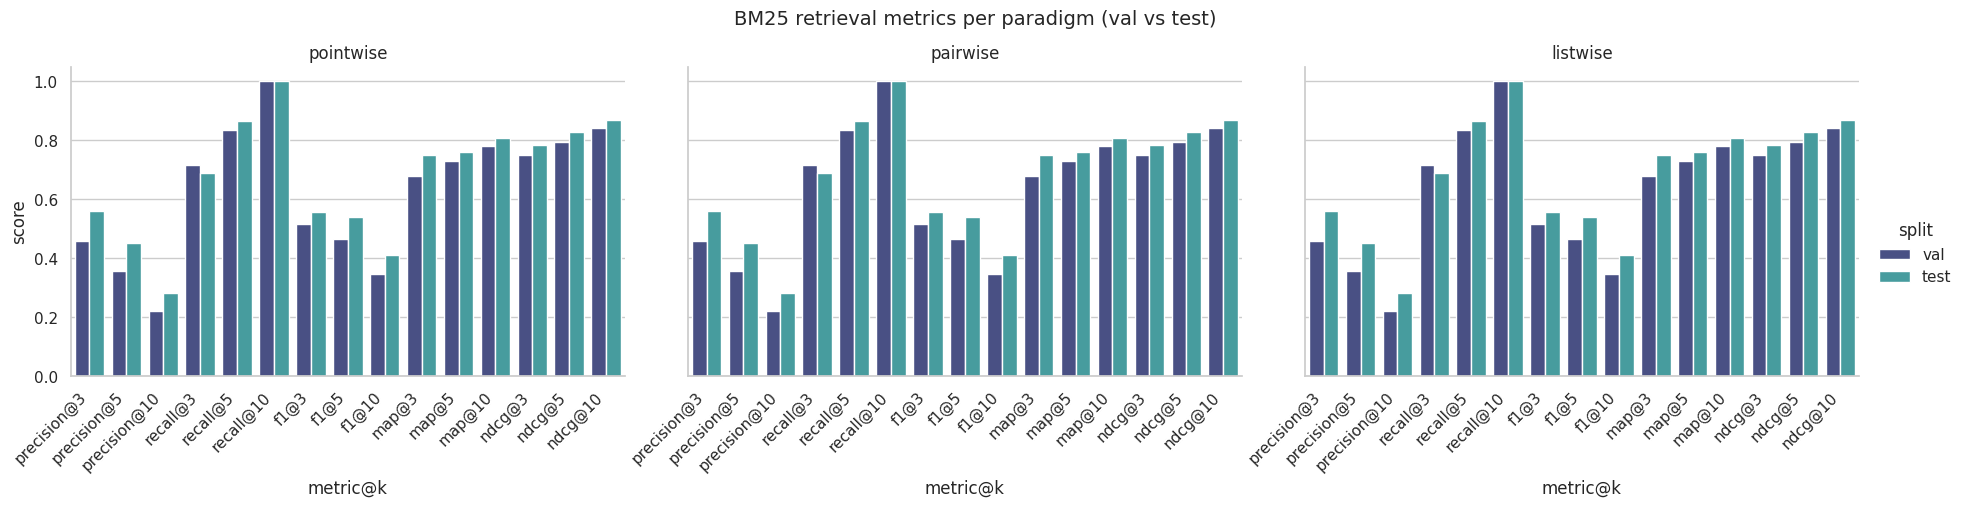

[BM25] saved /kaggle/working/plot_BM25.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plot_df = log_df.copy()
plot_df['metric_k'] = plot_df['metric'] + '@' + plot_df['k'].astype(str)
metric_order = [f'{m}@{k}' for m in METRIC_NAMES for k in K_VALUES]

g = sns.catplot(data=plot_df, x='metric_k', y='score', hue='split', col='paradigm', kind='bar',
                palette='mako', order=metric_order, col_order=PARADIGMS, height=4.2, aspect=1.5)
g.set_axis_labels('metric@k', 'score')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
g.fig.suptitle(f'{model} retrieval metrics per paradigm (val vs test)', y=1.04, fontsize=14)
g.savefig(f'{WORK_DIR}/plot_{model}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[{model}] saved {WORK_DIR}/plot_{model}.png')